In [46]:
import pandas as pd

rfm = pd.read_csv("/Users/dishasanthosh/Library/CloudStorage/OneDrive-Personal/Uni/Projects/retail-ds-project/data/customer_rfm.csv")
df = pd.read_csv("/Users/dishasanthosh/Library/CloudStorage/OneDrive-Personal/Uni/Projects/retail-ds-project/data/clean_transactions.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [47]:
#inspect

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,1,77183.60
1,12347.0,1,7,4310.00
2,12348.0,74,4,1797.24
3,12349.0,18,1,1757.55
4,12350.0,309,1,334.40


In [48]:
rfm['Recency'].describe()

count    4338.000000
mean       91.536422
std       100.014169
min         0.000000
25%        17.000000
50%        50.000000
75%       141.000000
max       373.000000
Name: Recency, dtype: float64

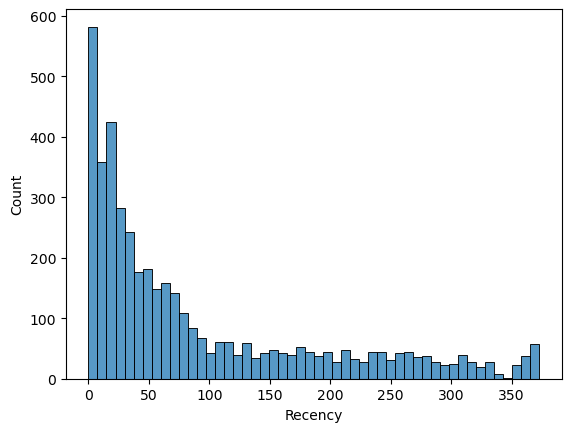

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(rfm['Recency'], bins=50)
plt.show()


In [50]:
#define/create churn (90days) : 1 -> churned ; 0 -> active
rfm['Churn'] = (rfm['Recency'] > 90).astype(int)


In [51]:
rfm['Churn'].value_counts()
rfm['Churn'].value_counts(normalize=True)


Churn
0    0.666897
1    0.333103
Name: proportion, dtype: float64

In [52]:
#define features and targets

X = rfm[[ 'Frequency', 'Monetary']]
y = rfm['Churn']


In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)


In [54]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, random_state=42)

In [55]:
from sklearn.metrics import classification_report, roc_auc_score

pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))


              precision    recall  f1-score   support

           0       0.71      0.73      0.72       579
           1       0.43      0.40      0.42       289

    accuracy                           0.62       868
   macro avg       0.57      0.57      0.57       868
weighted avg       0.62      0.62      0.62       868

ROC-AUC: 0.6497570683256538


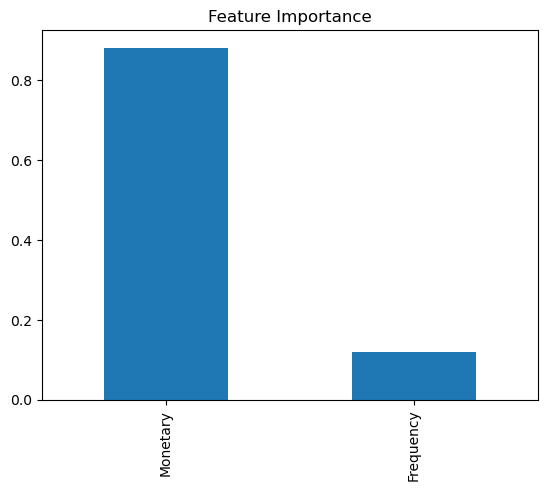

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.plot(kind='bar')
plt.title("Feature Importance")
plt.show()


In [57]:
customer_tenure = df.groupby('CustomerID')['InvoiceDate'].agg(['min', 'max'])
customer_tenure['Tenure'] = (
    customer_tenure['max'] - customer_tenure['min']
).dt.days

customer_tenure = customer_tenure[['Tenure']].reset_index()


In [58]:
rfm = rfm.merge(customer_tenure, on='CustomerID')


In [59]:
#average order value
aov = df.groupby('CustomerID')['TotalPrice'].mean().reset_index()
aov.columns = ['CustomerID', 'AvgOrderValue']

rfm = rfm.merge(aov, on='CustomerID')


In [60]:
#purchase frequency rate
rfm['FrequencyRate'] = rfm['Frequency'] / (rfm['Tenure'] + 1)


In [61]:
#revenue per day
rfm['RevenuePerDay'] = rfm['Monetary'] / (rfm['Tenure'] + 1)


In [62]:
#retrain
X = rfm[['Frequency', 'Monetary', 'Tenure',
         'AvgOrderValue', 'FrequencyRate', 'RevenuePerDay']]

y = rfm['Churn']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)


In [63]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [64]:
pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))

              precision    recall  f1-score   support

           0       0.74      0.80      0.77       579
           1       0.52      0.44      0.48       289

    accuracy                           0.68       868
   macro avg       0.63      0.62      0.62       868
weighted avg       0.67      0.68      0.67       868

ROC-AUC: 0.7463052273637282


In [65]:


proba = model.predict_proba(X_test)[:, 1]

threshold = 0.35
pred_adjusted = (proba > threshold).astype(int)

print(classification_report(y_test, pred_adjusted))

print("ROC-AUC:", roc_auc_score(y_test, proba))


              precision    recall  f1-score   support

           0       0.80      0.68      0.73       579
           1       0.50      0.65      0.57       289

    accuracy                           0.67       868
   macro avg       0.65      0.67      0.65       868
weighted avg       0.70      0.67      0.68       868

ROC-AUC: 0.7463052273637282


In [66]:
rfm.to_csv("/Users/dishasanthosh/Library/CloudStorage/OneDrive-Personal/Uni/Projects/retail-ds-project/data/customer_features.csv", index=False)

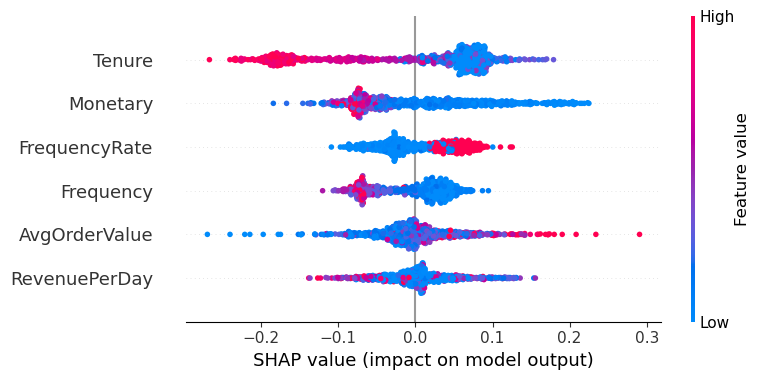

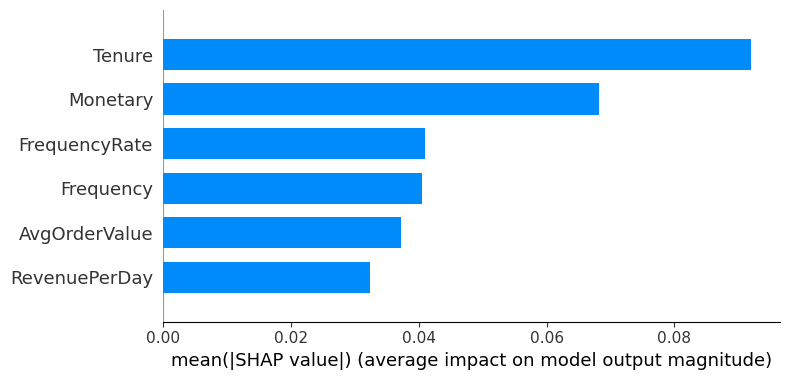

In [67]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap_values_churn = shap_values[:, :, 1]

shap.summary_plot(shap_values_churn, X_test)

shap.summary_plot(shap_values_churn, X_test, plot_type="bar")